In [74]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Proyecto: 

## Justificación del problema

La empresa M&S cuenta con un aplicativo web para la gestión de productos químicos. En la base de datos, se cuenta con información relacionada a los productos directamente relacionada con la información de las Fichas de Datos de Seguridad (FDS), que hace la función de la hoja de vida del producto. Debido a la gran variabilidad en la forma en que estos pueden ser nombrados, se tiene un problema actual en donde se cuenta con aproximadamente el 7% de productos repetidos y tiempos altos en la consolidación de inventarios. 

Los clientes que usan el aplicativo, cuentan con información relacionada al nombre interno que la organización destina para el producto. De esta manera, un mismo producto puede aparecer registrado con múltiples variantes de nombre, diferencias en abreviaturas, idioma, formato o referencia comercial. Por ejemplo, un mismo producto puede registrarse como:

* NaOH 0.1N Cleaning Solution

* 0.1 N Sodium Hydroxide Solution

* NaOH 0.1N cuvette cleaning solution

Ante este contexto, es de alta importancia desarrollar mecanismos que permitan identificar automáticamente qué productos del catálogo existente son más similares a un nuevo registro, a partir de la información disponible como el nombre del producto y su fabricante.

Un sistema que sugiera coincidencias probables permitiría:

* reducir la creación de duplicados,

* mejorar la calidad y consistencia del catálogo de productos,

* facilitar la búsqueda y recuperación de información dentro del sistema,

* optimizar procesos de gestión de inventarios químicos.

Por esta razón, resulta relevante explorar el uso de técnicas de aprendizaje automático y representaciones semánticas del texto que permitan calcular similitudes entre productos y sugerir automáticamente las coincidencias más probables dentro del catálogo existente.

## Objetivo
Desarrollar un modelo de Deep Learning, el cual con el nombre y fabricante de un producto químico ingresado por el usuario, identifique los productos más similares en el catálogo existente, devolviendo un ranking de coincidencias probables.

## Metodología

1. Estructura inicial de los datos

    El dataset de productos se divide en dos subconjuntos dependiendo de la disponibilidad de información adicional.

    * df_con_sin_o_uso: Productos que tienen información en uso o sinónimo. Tamaño aproximado: (50621, 5)

    * df_sin_sin_o_uso: Productos que NO tienen información ni en sinonimos ni en uso. Tamaño aproximado: (13874, 5)

    La motivación de la separación nace porque los productos que tienen más información contextual permiten construir mejores representaciones semánticas para el modelo.

    Sin embargo, ambos datasets siguen siendo parte del mismo catálogo y pueden utilizarse en el sistema final.

2. Limpieza y normalización de texto

    Se aplican transformaciones para estandarizar el texto:

    - convertir texto a minúsculas
    - eliminar caracteres especiales innecesarios
    - eliminar espacios duplicados
    - reemplazar valores nulos por cadenas vacías

3. Construcción del texto base del producto

    - Para cada producto se construye un texto consolidado con la información disponible.

        - texto_producto = nombre_producto + fabricante + sinonimos + uso

    - Si un producto no tiene sinonimos o uso, se construye únicamente con la información disponible.

4. Vectorización de productos
   - El texto consolidado de cada producto se transforma en una representación numérica.
   - Esta vectorización permite comparar productos en un espacio común.
   - En esta etapa todavía no se hace la predicción final, sino que se prepara la información para agrupar y analizar.

5. Clustering del catálogo
   - Sobre los vectores generados se aplica un algoritmo de clustering.
   - El objetivo es identificar grupos naturales de productos similares dentro del catálogo.

    Propósitos del clustering:
    - encontrar agrupaciones de productos parecidos
    - identificar posibles familias de productos
    - reducir el espacio de búsqueda para la predicción posterior
    - detectar registros potencialmente duplicados o muy cercanos

6. Análisis de clusters
   - Se revisa la composición de cada cluster.
   - Se analiza si los productos agrupados comparten patrones de nombre, fabricante, sinónimos o uso.
   - Se valida si los clusters realmente separan bien tipos de productos.
   - A partir de este análisis se pueden ajustar variables, limpieza o estrategia de vectorización.

7. Modelo de predicción / recuperación
   - Una vez estructurado el catálogo mediante clusters, se construye el sistema de predicción.
   - Cuando entra un producto nuevo:
       1. se limpia el texto de entrada
       2. se construye su texto consolidado
       3. se vectoriza usando la misma lógica del catálogo
       4. se identifica el cluster más probable o más cercano
       5. se compara solo contra los productos de ese cluster, o contra todo el catálogo si se requiere
       6. se genera un ranking de similitud


8. Evaluación del sistema
   - Se revisa si las sugerencias son coherentes.
   - Se valida si el producto correcto aparece dentro del top 5, top 10 o top 20.
   - Se analiza el aporte del clustering frente a una búsqueda directa sin agrupación previa.

9. Exposición mediante API
   - Se implementa un servicio con FastAPI.
   - El servicio recibe:
       nombre_producto
       fabricante
   - Internamente:
       limpia
       vectoriza
       identifica cluster
       calcula similitud
       devuelve ranking

   Salida:
       lista de productos más similares con score

## Carga de datos

In [5]:
df = pd.read_excel("listado productos.xlsx").iloc[:, 1:]
df

,id,nombre_producto,sinonimos,uso,fabricante
0,30818,0 1 m dtt,superscript iv first strand synthesis system |...,para uso en investigacion unicamente,thermofisher scientific
1,56997,0 1n naoh compartimiento r1b,access hstni b52699,NaN,beckman coulter
2,10421,0 1n naoh cuvette cleaning solution b,7098 10445578,agentes de diagn oacute stico,siemens healthcare
3,42583,0 45 m 47mm white gridded s pak filter membran...,NaN,investigacion y analisis bioquimicos,merck
4,56156,0 5 medios de crecimiento b de postgate modifi...,NaN,NaN,grupo volante
...,...,...,...,...,...
64490,35967,zytiga,zytiga abiraterone acetate abiraterone acetate...,producto farmaceutico terminado grupo farmacot...,janssen
64491,1360,zytokil 10mg 5ml,doxorubicina,no registra,pisa farmaceutica
64492,26325,zz76 01009 citrus passion,NaN,NaN,ungerer & company
64493,62579,zzliteprop prime 108 alt code l426802 00,NaN,NaN,grupo transmerquim


In [6]:
cols_normales = [c for c in df.columns if c != "sinonimos"]

df[cols_normales] = df[cols_normales].replace("no registra", np.nan)

def limpiar_sinonimos(texto):
    if pd.isna(texto):
        return texto
    
    partes = [p.strip() for p in texto.split("|")]
    partes = [p for p in partes if p.lower() != "no registra"]
    
    if len(partes) == 0:
        return np.nan
        
    return "|".join(partes)

df["sinonimos"] = df["sinonimos"].apply(limpiar_sinonimos)

In [7]:
# Separar el DataFrame en dos
# Uno con al menos un sinónimo o un uso
df_con_sin_o_uso = df[(df['sinonimos'].notna() & (df['sinonimos'] != '')) | (df['uso'].notna() & (df['uso'] != ''))]

# El otro con los demás
df_sin_sin_o_uso = df[~((df['sinonimos'].notna() & (df['sinonimos'] != '')) | (df['uso'].notna() & (df['uso'] != '')))]

print("DataFrame con sinónimo o uso:")
print(df_con_sin_o_uso.shape)
print("\nDataFrame sin sinónimo o uso:")
print(df_sin_sin_o_uso.shape)

DataFrame con sinónimo o uso:
(47170, 5)

DataFrame sin sinónimo o uso:
(17325, 5)


## 3. Construcción del texto base 

In [8]:
# Seleccionar columnas categóricas para clustering
# Completamos los valores faltantes con cadena vacía para evitar problemas con los modelos venideros

df_modelo = df.copy()

df_modelo["nombre_producto"] = df_modelo["nombre_producto"].fillna("")
df_modelo["sinonimos"] = df_modelo["sinonimos"].fillna("")
df_modelo["uso"] = df_modelo["uso"].fillna("")
df_modelo["fabricante"] = df_modelo["fabricante"].fillna("")

In [ ]:
# Crear una nueva columna que combine las columnas de texto para el clustering

df_modelo["texto_producto"] = (
    df_modelo["nombre_producto"] + " " +
    df_modelo["nombre_producto"] + " " +   # duplicamos nombre para darle peso
    df_modelo["fabricante"] + " " +
    df_modelo["sinonimos"] + " " +
    df_modelo["uso"]
).str.lower().str.replace(r"\s+", " ", regex=True).str.strip()

df_modelo[["id", "texto_producto"]].head(10)

,id,texto_producto
0,30818,0 1 m dtt 0 1 m dtt thermofisher scientific su...
1,56997,0 1n naoh compartimiento r1b 0 1n naoh compart...
2,10421,0 1n naoh cuvette cleaning solution b 0 1n nao...
3,42583,0 45 m 47mm white gridded s pak filter membran...
4,56156,0 5 medios de crecimiento b de postgate modifi...
5,36322,0 ftu turbidity calibration standard 0 ftu tur...
6,66080,000000026354 hth ph minus 000000026354 hth ph ...
7,43858,000000026354 hth ph minus 000000026354 hth ph ...
8,11166,000113 b iris 000113 b iris firmenich
9,11160,000136 btr bergamote 000136 btr bergamote firm...


## 4. Vectorización de texto

### Usando embeddings

In [10]:
# pip install sentence-transformers

In [11]:
# Importar el modelo de Sentence Transformers
# El modelo permite trabajo de embbedings de texto, lo que es útil para clustering semántico en ingles y español. 
# Se ajusta a los datos que se están trabajando.
from sentence_transformers import SentenceTransformer

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
# Cargar el modelo preentrenado
modelo_embeddings = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13474.10it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Generar los embeddings para el texto del producto
embeddings = modelo_embeddings.encode(
    df_modelo["texto_producto"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(type(embeddings))
print(embeddings.shape)

Batches: 100%|██████████| 1008/1008 [01:29<00:00, 11.32it/s]

<class 'numpy.ndarray'>
(64495, 384)


In [65]:
kmeans = KMeans(n_clusters=80, random_state=42, n_init=10)
df_modelo["cluster_id"] = kmeans.fit_predict(embeddings)

In [71]:
tam_clusters = (
    df_modelo["cluster_id"]
    .value_counts()
    .sort_index()
    .reset_index()
)

tam_clusters.columns = ["cluster_id", "cantidad_productos"]
tam_clusters.head(10)

,cluster_id,cantidad_productos
0,0,180
1,1,410
2,2,1179
3,3,416
4,4,652
5,5,456
6,6,1304
7,7,406
8,8,351
9,9,598


In [75]:
cluster_ejemplo = 10
df_modelo[df_modelo["cluster_id"] == cluster_ejemplo][
    ["id", "nombre_producto", "fabricante", "sinonimos", "uso"]
].head(10)

,id,nombre_producto,fabricante,sinonimos,uso
365,60937,1 x 1 ml mitochondrial ama pattern 098526,inova diagnostics,,
366,60938,1 x 1 ml smooth muscle asma pattern 097500,inova diagnostics,,
382,60942,10 rat liver kidney stomach slide 5 well 098361,inova diagnostics,,
431,35898,10009049 anticorrosivo negro 200,pintuco,anticorrosivo negro 200 10012444 10014322 1001...,pintura
777,12245,17hidroxi progesterona,diasource immunoassays,,diagn oacute stico in vitro
1327,27207,3 en uno profesional grasa blanca de litio,wd-40 company,grasa blanca de litio|filmarray pneumonia pane...,lubricante
1485,46595,3m attest super rapid readout biological indic...,3m colombia,42 0026 1608 6 43 7800 1785 1 43 7800 2117 6 4...,para indicar el alcance de las condiciones de ...
1530,41309,3m mda listeria monocytogenes 2,3m españa,3m molecular detection assay listeria monocyto...,ensayos microbiologicos
1533,41310,3m molecular detection positive control,3m españa,3m molecular detection assay listeria monocyto...,profesional
1919,7737,4nc citrato 3 na,aquisel,4nc citrato 3 na vsg ers,anticoagulante sanguineo determinacion de velo...


In [73]:
tam_clusters = (
    df_modelo["cluster_id"]
    .value_counts()
    .sort_index()
    .reset_index()
)
tam_clusters.columns = ["cluster_id", "cantidad_productos"]

muestra_clusters = (
    df_modelo
    .groupby("cluster_id", group_keys=False)
    .apply(lambda x: x.sample(min(2, len(x)), random_state=42))
    .sort_values(["cluster_id", "nombre_producto"])
    .reset_index(drop=True)
)

muestra_clusters = muestra_clusters.merge(
    tam_clusters,
    on="cluster_id",
    how="left"
)

display(
    muestra_clusters[
        ["cluster_id", "cantidad_productos", "id", "nombre_producto", "fabricante", "sinonimos", "uso"]
    ]
)

muestra_clusters.to_excel("muestra_2_productos_por_cluster.xlsx", index=False)

,cluster_id,cantidad_productos,id,nombre_producto,fabricante,sinonimos,uso
0,0,180,52734,carbon activado,atlas copco,coal gn uc h,adsorvente adsorcion por oscilacion de presion
1,0,180,1607,carbon activo granulos,merck,,an aacute lisis qu iacute mico
2,1,410,39086,fosfuro de aluminio 57 ft fumigeno en tableta,anasac,detia gas,insecticida de uso agricola
3,1,410,56017,herbicida panzer,invesa,,
4,2,1179,36659,4411 rellenador de espuma de prepolimero eliminar,3m colombia,4411 foam filler prepolymer eliminar,componente de un kit sellante
...,...,...,...,...,...,...,...
155,77,844,59429,hi70451 0 free chlorine buffer solution,hanna instruments,,reactivo controlador de procesos utilizados en...
156,78,1364,11791,968392 orange 10 x conc,firmenich,,
157,78,1364,39691,key 1000,key quimica,171 172 74 174 75 2279 7520 36008,detergente
158,79,303,54570,latex 832 black,hp colombia,,


In [76]:
valores_k = [10, 20, 30, 40, 50, 60, 80, 100]

resultados = []

for k in valores_k:
    
    print(f"Probando k = {k}")
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(embeddings)
    
    score = silhouette_score(embeddings, labels)
    
    resultados.append({
        "k": k,
        "silhouette_score": score
    })

df_silhouette = pd.DataFrame(resultados)

df_silhouette

Probando k = 10
Probando k = 20
Probando k = 30
Probando k = 40
Probando k = 50
Probando k = 60
Probando k = 80
Probando k = 100


,k,silhouette_score
0,10,0.041751
1,20,0.037092
2,30,0.036662
3,40,0.037796
4,50,0.038017
5,60,0.039857
6,80,0.038913
7,100,0.040875


In [77]:
df_silhouette.sort_values("silhouette_score", ascending=False)

,k,silhouette_score
0,10,0.041751
7,100,0.040875
5,60,0.039857
6,80,0.038913
4,50,0.038017
3,40,0.037796
1,20,0.037092
2,30,0.036662


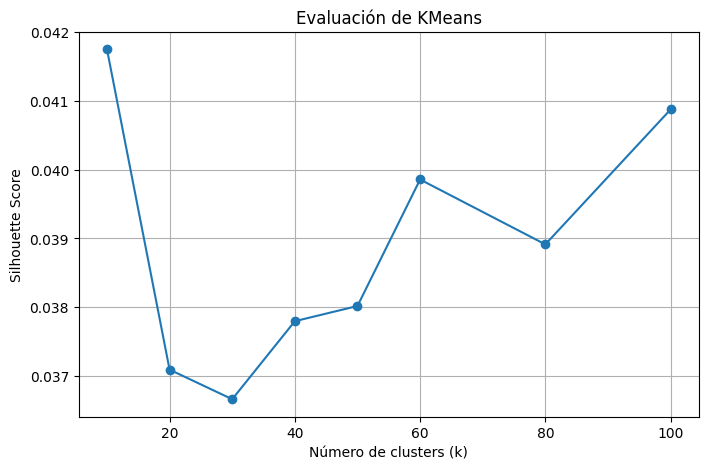

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    df_silhouette["k"],
    df_silhouette["silhouette_score"],
    marker="o"
)

plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Evaluación de KMeans")
plt.grid(True)

plt.show()

In [81]:
from sklearn.cluster import KMeans

kmeans_10 = KMeans(n_clusters=10, random_state=42, n_init=10)
clusters_10 = kmeans_10.fit_predict(embeddings)

kmeans_60 = KMeans(n_clusters=60, random_state=42, n_init=10)
clusters_60 = kmeans_60.fit_predict(embeddings)

df_modelo["cluster_10"] = clusters_10
df_modelo["cluster_60"] = clusters_60

In [82]:
tam_clusters_10 = (
    df_modelo["cluster_10"]
    .value_counts()
    .sort_index()
    .reset_index()
)
tam_clusters_10.columns = ["cluster_id", "cantidad_productos"]

tam_clusters_60 = (
    df_modelo["cluster_60"]
    .value_counts()
    .sort_index()
    .reset_index()
)
tam_clusters_60.columns = ["cluster_id", "cantidad_productos"]

display(tam_clusters_10)
display(tam_clusters_60)

,cluster_id,cantidad_productos
0,0,6184
1,1,10173
2,2,6438
3,3,4882
4,4,6162
5,5,6316
6,6,3307
7,7,8815
8,8,4125
9,9,8093


,cluster_id,cantidad_productos
0,0,371
1,1,410
2,2,1358
3,3,1371
4,4,1454
5,5,826
6,6,539
7,7,398
8,8,1230
9,9,964


## 5. Clustering de los datos